# Configurando 

In [204]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

print("✓ Bibliotecas importadas com sucesso!")
print(f"MediaPipe versão: {mp.__version__}")
print(f"OpenCV versão: {cv2.__version__}")

✓ Bibliotecas importadas com sucesso!
MediaPipe versão: 0.10.33
OpenCV versão: 4.13.0


# Carregando video todo

Vídeos disponíveis na pasta 'gym_videos':
  1. Camera de segurança de academia flagra aluno após treino de pernas, o final é surpresa! 🚨.mp4
  2. Como ativar mais o bíceps no treino de bíceps.mp4

Usando: gym_videos\Como ativar mais o bíceps no treino de bíceps.mp4

📹 Informações do Vídeo:
  Dimensões: 640x360
  FPS: 29.97
  Total de Frames: 15756
  Duração: 525.73 segundos (8m45s)

✓ Primeiro frame carregado!


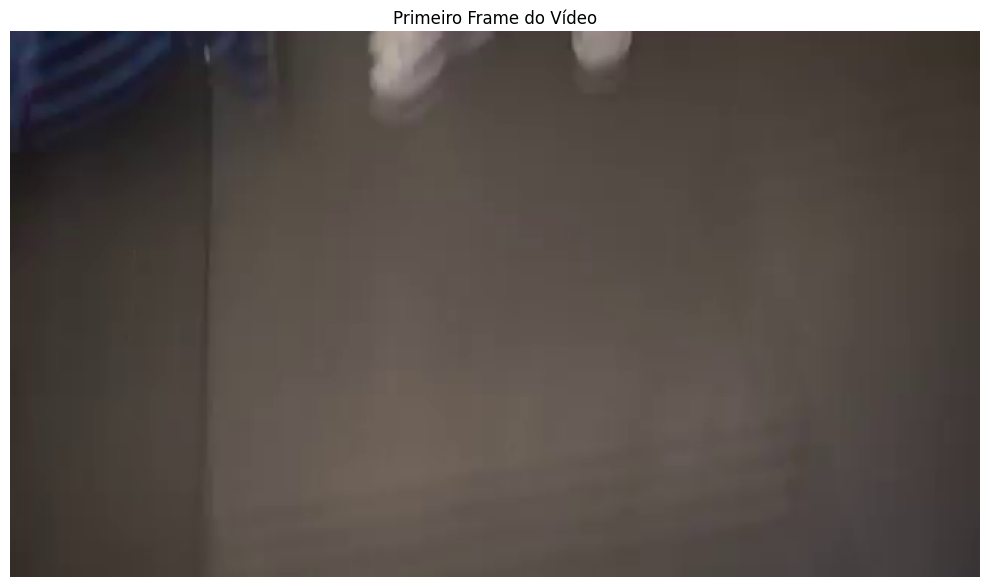

In [205]:
# Configurações do vídeo
video_path = "gym_videos"  # Pasta onde os vídeos são salvos

# Listar vídeos disponíveis
video_files = list(Path(video_path).glob("*.mp4"))

if video_files:
    print(f"Vídeos disponíveis na pasta '{video_path}':")
    for i, file in enumerate(video_files, 1):
        print(f"  {i}. {file.name}")
    
    # Usar o primeiro vídeo disponível
    selected_video = str(video_files[1])
    print(f"\nUsando: {selected_video}")
else:
    print(f"Nenhum vídeo encontrado em '{video_path}'")
    print("Use o script download_gym_video.py para baixar um vídeo primeiro!")
    selected_video = None

# Se houver vídeo, carregar suas informações
if selected_video and os.path.exists(selected_video):
    cap = cv2.VideoCapture(selected_video)
    
    # Obter propriedades do vídeo
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps if fps > 0 else 0
    
    print(f"\n📹 Informações do Vídeo:")
    print(f"  Dimensões: {width}x{height}")
    print(f"  FPS: {fps:.2f}")
    print(f"  Total de Frames: {frame_count}")
    print(f"  Duração: {duration:.2f} segundos ({int(duration//60)}m{int(duration%60)}s)")
    
    # Ler e exibir o primeiro frame
    ret, frame = cap.read()
    if ret:
        print("\n✓ Primeiro frame carregado!")
        # Redimensionar para exibição
        display_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(display_frame)
        plt.title("Primeiro Frame do Vídeo")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    
    cap.release()

# Selecionando apenas um frame

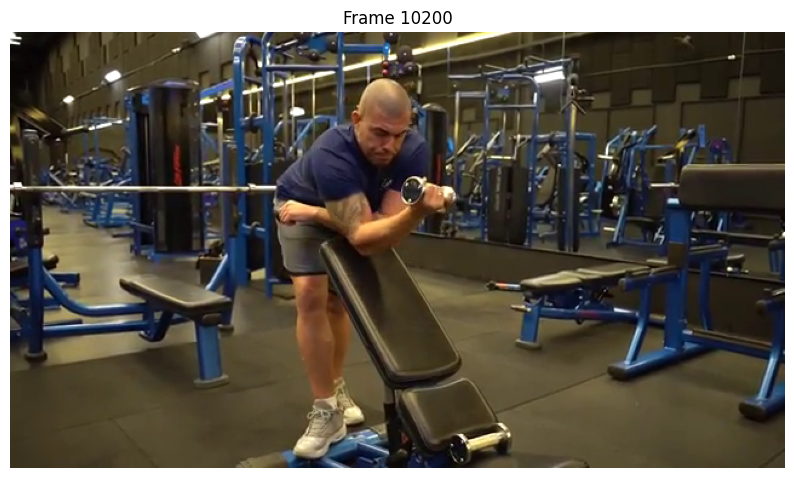

In [206]:
cap = cv2.VideoCapture(selected_video)

# Ir para o frame número 150
frame_number = 10200
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()
if ret:
    display_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(display_frame)
    plt.title(f"Frame {frame_number}")
    plt.axis("off")
    plt.show()

cap.release()

# Fazendo a predição dos pontos 

In [207]:
# Setup do MediaPipe Pose Landmarker
model_path = 'models/pose_landmarker_heavy.task'

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# Criar opções do PoseLandmarker
options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.IMAGE,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
)

# Criar instância do PoseLandmarker
landmarker = PoseLandmarker.create_from_options(options)

print("✓ MediaPipe Pose Landmarker inicializado com sucesso!")
print(f"  Modelo: {model_path}")

✓ MediaPipe Pose Landmarker inicializado com sucesso!
  Modelo: models/pose_landmarker_heavy.task


In [208]:
# Converter frame para MediaPipe Image
image = mp.Image(image_format=mp.ImageFormat.SRGB, 
                data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# # Executar pose detection
pose_landmarker_result = landmarker.detect(image)
pose_landmarker_result.pose_landmarks[0][0]

NormalizedLandmark(x=0.48922842741012573, y=0.26064085960388184, z=-0.5428428053855896, visibility=0.9999542236328125, presence=0.9999986886978149, name=None)

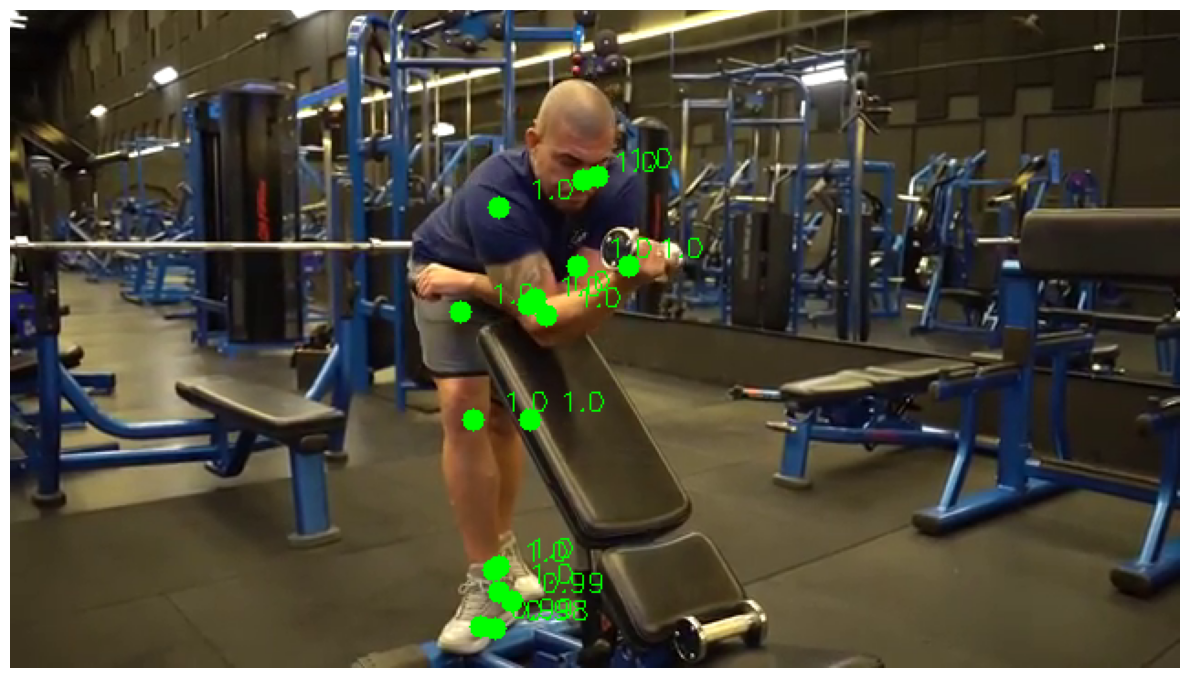

In [211]:
# Selecionar pontos: nariz + pulso esquerdo + resto do corpo
selected_landmarks = [
    0,                          # Nariz (rosto)
    15, 16,                      # Pulso esquerdo (mãos)
    11, 12,                     # Ombros
    13, 14,                     # Cotovelos
    23, 24,                     # Quadris
    25, 26,                     # Joelhos
    27, 28,                     # Tornozelos
    29, 30, 31, 32              # Pés
]

h, w, c = frame.shape
frame_copy = frame.copy()

landmark_names = {
    0: "Nariz",
    15: "Pulso Esq.",
    11: "Ombro Esq.", 12: "Ombro Dir.",
    13: "Cotovelo Esq.", 14: "Cotovelo Dir.", 16: "Pulso Dir.",
    23: "Quad Esq.", 24: "Quad Dir.",
    25: "Joelho Esq.", 26: "Joelho Dir.",
    27: "Tornozelo Esq.", 28: "Tornozelo Dir.",
    29: "Calcanhar Esq.", 30: "Calcanhar Dir.",
    31: "Pé Esq.", 32: "Pé Dir."
}

for idx in selected_landmarks:
    landmark = pose_landmarker_result.pose_landmarks[0][idx]
    
    if landmark.presence < 0.50:
        continue
    
    x_px = int(landmark.x * w)
    y_px = int(landmark.y * h)
    
    cv2.circle(frame_copy, (x_px, y_px), 6, (0, 255, 0), -1)
    # cv2.putText(frame_copy, f" {round(landmark.presence,2)}", (x_px + 8, y_px - 5), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    cv2.putText(frame_copy, f" {round(landmark.presence,2)}", (x_px + 8, y_px - 5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    # cv2.putText(frame_copy, f"{landmark_names[idx]}: {round(landmark.presence,1)}", (x_px + 8, y_px - 5), 
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

display_frame = cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(display_frame)
plt.axis('off')
plt.tight_layout()
plt.show()

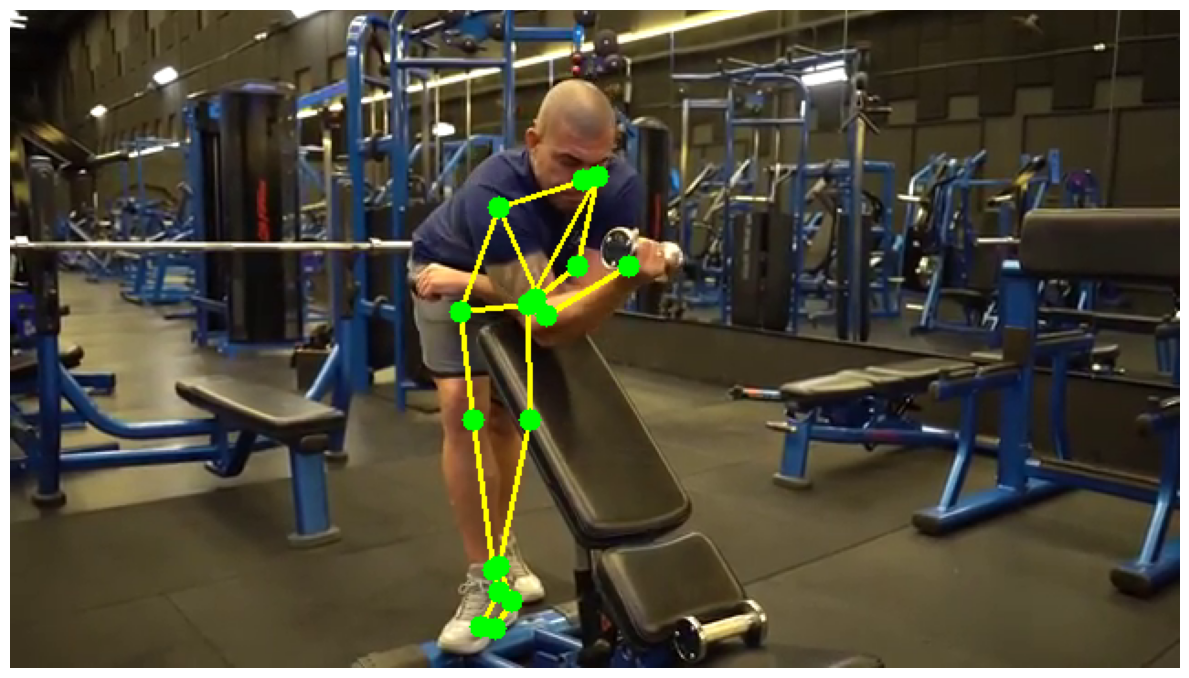

In [212]:
# Selecionar pontos: nariz + pulso esquerdo + resto do corpo
selected_landmarks = [
    0,                          # Nariz (rosto)
    15, 16,                     # Pulsos (mãos)
    11, 12,                     # Ombros
    13, 14,                     # Cotovelos
    23, 24,                     # Quadris
    25, 26,                     # Joelhos
    27, 28,                     # Tornozelos
    29, 30, 31, 32              # Pés
]

# Definir conexões entre os pontos
connections = [
    (12, 11),           # Nariz -> Ombros
    (11, 13), (13, 15),         # Ombro esq -> Cotovelo esq -> Pulso esq
    (12, 14), (14, 16),         # Ombro dir -> Cotovelo dir -> Pulso dir
    (11, 23), (12, 24),         # Ombros -> Quadris
    (23, 24),                   # Quadril esq -> Quadril dir
    (23, 25), (25, 27),         # Quadril esq -> Joelho esq -> Tornozelo esq
    (27, 29), (29, 31),         # Tornozelo esq -> Calcanhar esq -> Pé esq
    (24, 26), (26, 28),         # Quadril dir -> Joelho dir -> Tornozelo dir
    (28, 30), (30, 32),         # Tornozelo dir -> Calcanhar dir -> Pé dir
]

h, w, c = frame.shape
frame_copy = frame.copy()

landmark_names = {
    0: "Nariz",
    15: "Pulso Esq.", 16: "Pulso Dir.",
    11: "Ombro Esq.", 12: "Ombro Dir.",
    13: "Cotovelo Esq.", 14: "Cotovelo Dir.",
    23: "Quad Esq.", 24: "Quad Dir.",
    25: "Joelho Esq.", 26: "Joelho Dir.",
    27: "Tornozelo Esq.", 28: "Tornozelo Dir.",
    29: "Calcanhar Esq.", 30: "Calcanhar Dir.",
    31: "Pé Esq.", 32: "Pé Dir."
}

# Desenhar conexões (linhas)
for start_idx, end_idx in connections:
    start_landmark = pose_landmarker_result.pose_landmarks[0][start_idx]
    end_landmark = pose_landmarker_result.pose_landmarks[0][end_idx]
    
    if start_landmark.presence < 0.5 or end_landmark.presence < 0.5:
        continue
    
    start_x = int(start_landmark.x * w)
    start_y = int(start_landmark.y * h)
    end_x = int(end_landmark.x * w)
    end_y = int(end_landmark.y * h)
    
    cv2.line(frame_copy, (start_x, start_y), (end_x, end_y), (0, 255, 255), 2)  # Amarelo

# Desenhar círculos nos pontos
for idx in selected_landmarks:
    landmark = pose_landmarker_result.pose_landmarks[0][idx]
    
    if landmark.presence < 0.50:
        continue
    
    x_px = int(landmark.x * w)
    y_px = int(landmark.y * h)
    
    cv2.circle(frame_copy, (x_px, y_px), 6, (0, 255, 0), -1)  # Verde


display_frame = cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(display_frame)
plt.axis('off')
plt.tight_layout()
plt.show()